In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
import os

print(os.listdir())


['Output', '.ipynb_checkpoints', 'Report', 'Data', 'anaconda_projects', 'DataScales.ipynb']


In [9]:
import os

print("Current Jupyter folder:")
print(os.getcwd())

Current Jupyter folder:
/home/admin1/Sales_Analysis_Project


In [10]:
import os

matches = []

for root, dirs, files in os.walk(os.path.expanduser("~")):
    if "train.csv" in files:
        matches.append(os.path.join(root, "train.csv"))

print("Found files:")
for file in matches:
    print(file)

Found files:
/home/admin1/Downloads/train.csv
/home/admin1/Sales_Analysis_Project/Data/train.csv


In [15]:
df = pd.read_csv("/home/admin1/Sales_Analysis_Project/Data/train.csv")

print("Dataset loaded successfully!")


Dataset loaded successfully!


In [16]:
print("Number of rows:", len(df))
print("Number of columns:", len(df.columns))

Number of rows: 9800
Number of columns: 18


In [17]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [35]:
print("Number of Rows:", df.shape[0])
print("Number of Columns:", df.shape[1])

Number of Rows: 9800
Number of Columns: 18


In [36]:
print(df.columns)

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales'],
      dtype='object')


In [37]:
df.dtypes

Row ID                    int64
Order ID                 object
Order Date       datetime64[ns]
Ship Date        datetime64[ns]
Ship Mode                object
Customer ID              object
Customer Name            object
Segment                  object
Country                  object
City                     object
State                    object
Postal Code             float64
Region                   object
Product ID               object
Category                 object
Sub-Category             object
Product Name             object
Sales                   float64
dtype: object

In [38]:
df["Order Date"] = pd.to_datetime(df["Order Date"], dayfirst=True)
df["Ship Date"] = pd.to_datetime(df["Ship Date"], dayfirst=True)

print(df[["Order Date", "Ship Date"]].dtypes)

Order Date    datetime64[ns]
Ship Date     datetime64[ns]
dtype: object


In [39]:
df.isnull().sum()

Row ID              0
Order ID            0
Order Date       5841
Ship Date        5985
Ship Mode           0
Customer ID         0
Customer Name       0
Segment             0
Country             0
City                0
State               0
Postal Code        11
Region              0
Product ID          0
Category            0
Sub-Category        0
Product Name        0
Sales               0
dtype: int64

In [40]:
df["Postal Code"] = df["Postal Code"].fillna(0)

print("Total missing values:", df.isnull().sum().sum())

Total missing values: 11826


In [41]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [42]:

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9800 non-null   int64         
 1   Order ID       9800 non-null   object        
 2   Order Date     3959 non-null   datetime64[ns]
 3   Ship Date      3815 non-null   datetime64[ns]
 4   Ship Mode      9800 non-null   object        
 5   Customer ID    9800 non-null   object        
 6   Customer Name  9800 non-null   object        
 7   Segment        9800 non-null   object        
 8   Country        9800 non-null   object        
 9   City           9800 non-null   object        
 10  State          9800 non-null   object        
 11  Postal Code    9800 non-null   float64       
 12  Region         9800 non-null   object        
 13  Product ID     9800 non-null   object        
 14  Category       9800 non-null   object        
 15  Sub-Category   9800 n

In [43]:
df.describe()

,Row ID,Order Date,Ship Date,Postal Code,Sales
count,9800.000000,3959,3815,9800.000000,9800.000000
mean,4900.500000,2017-03-14 18:19:11.199798016,2017-04-09 17:04:02.516382720,55211.280918,230.769059
min,1.000000,2015-01-02 00:00:00,2015-01-04 00:00:00,0.000000,0.444000
25%,2450.750000,2016-04-05 00:00:00,2016-04-12 00:00:00,23223.000000,17.248000
50%,4900.500000,2017-05-02 00:00:00,2017-06-06 00:00:00,57551.000000,54.490000
75%,7350.250000,2018-03-07 00:00:00,2018-05-01 00:00:00,90008.000000,210.605000
max,9800.000000,2018-12-11 00:00:00,2019-05-01 00:00:00,99301.000000,22638.480000
std,2829.160653,NaN,NaN,32076.677954,626.651875


In [44]:
mean_sales = df["Sales"].mean()
median_sales = df["Sales"].median()
std_sales = df["Sales"].std()

print("Mean Sales:", mean_sales)
print("Median Sales:", median_sales)
print("Standard Deviation:", std_sales)

Mean Sales: 230.7690594591837
Median Sales: 54.489999999999995
Standard Deviation: 626.6518748388047


In [45]:
df["Year"] = df["Order Date"].dt.year
df["Month"] = df["Order Date"].dt.month
df["Month Name"] = df["Order Date"].dt.month_name()

df[["Order Date", "Year", "Month", "Month Name"]].head()

,Order Date,Year,Month,Month Name
0,2017-08-11,2017.0,8.0,August
1,2017-08-11,2017.0,8.0,August
2,2017-12-06,2017.0,12.0,December
3,2016-11-10,2016.0,11.0,November
4,2016-11-10,2016.0,11.0,November


In [46]:
yearly_sales = df.groupby("Year")["Sales"].sum()

print(yearly_sales)

Year
2015.0    176986.5857
2016.0    162568.8627
2017.0    266254.6009
2018.0    266553.0743
Name: Sales, dtype: float64


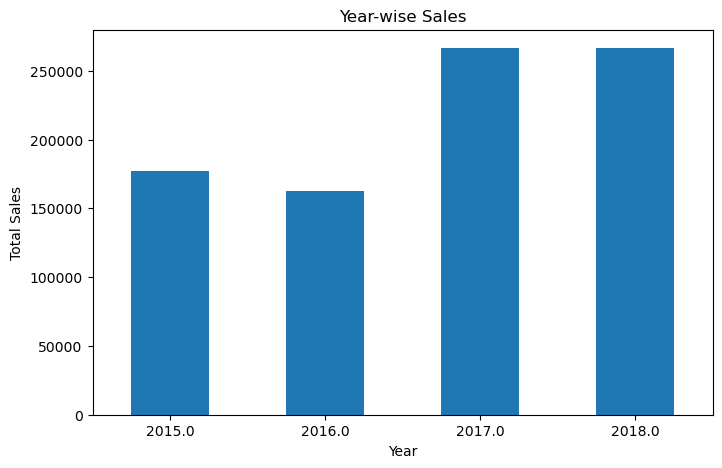

In [47]:
plt.figure(figsize=(8,5))

yearly_sales.plot(kind="bar")

plt.title("Year-wise Sales")
plt.xlabel("Year")
plt.ylabel("Total Sales")
plt.xticks(rotation=0)
plt.show()

In [48]:
monthly_sales = df.groupby(
    df["Order Date"].dt.to_period("M")
)["Sales"].sum()

monthly_sales.head()

Order Date
2015-01    19546.163
2015-02    11678.994
2015-03     6716.044
2015-04    12455.482
2015-05    15165.051
Freq: M, Name: Sales, dtype: float64

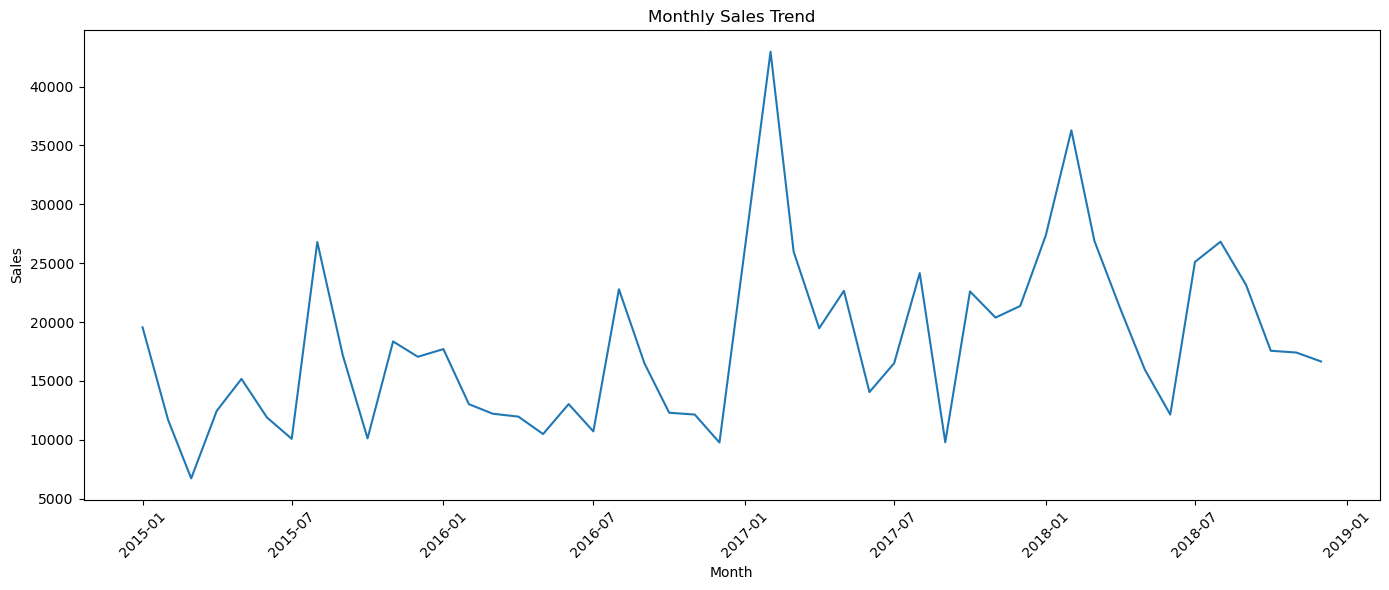

In [55]:
plt.figure(figsize=(14,6))

plt.plot(monthly_sales.index, monthly_sales.values)

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [56]:
category_sales = df.groupby("Category")["Sales"].sum().sort_values(ascending=False)

print(category_sales)

Category
Technology         827455.8730
Furniture          728658.5757
Office Supplies    705422.3340
Name: Sales, dtype: float64


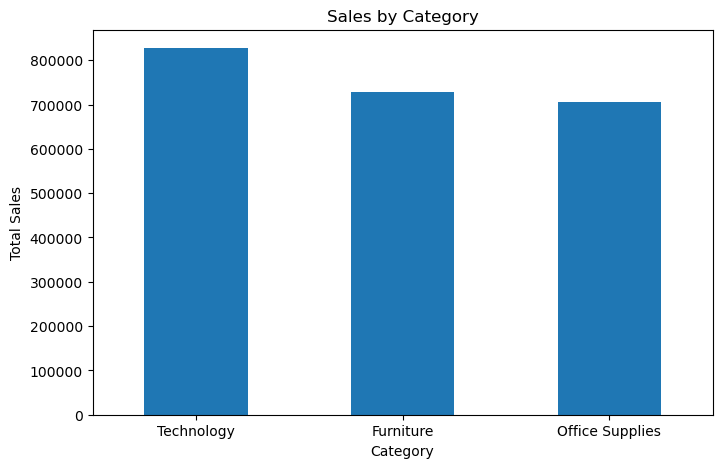

In [57]:
plt.figure(figsize=(8,5))

category_sales.plot(kind="bar")

plt.title("Sales by Category")
plt.xlabel("Category")
plt.ylabel("Total Sales")

plt.xticks(rotation=0)

plt.show()

In [58]:
region_sales = df.groupby("Region")["Sales"].sum().sort_values(ascending=False)

print(region_sales)

Region
West       710219.6845
East       669518.7260
Central    492646.9132
South      389151.4590
Name: Sales, dtype: float64


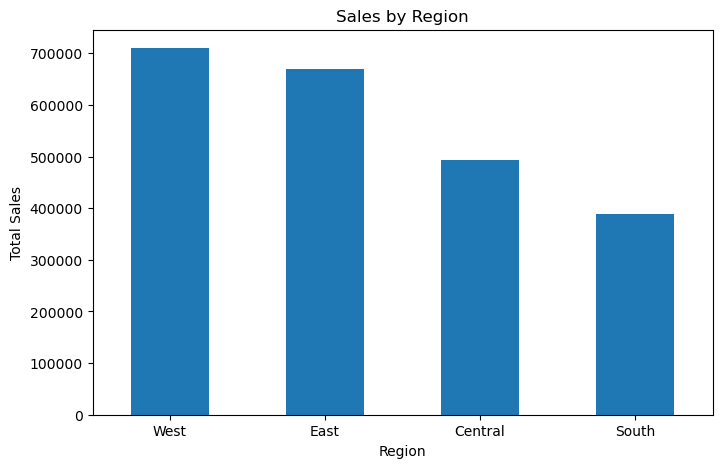

In [59]:
plt.figure(figsize=(8,5))

region_sales.plot(kind="bar")

plt.title("Sales by Region")
plt.xlabel("Region")
plt.ylabel("Total Sales")

plt.xticks(rotation=0)

plt.show()

In [60]:
subcategory_sales = df.groupby(
    "Sub-Category"
)["Sales"].sum().sort_values(ascending=False)

print(subcategory_sales)

Sub-Category
Phones         327782.4480
Chairs         322822.7310
Storage        219343.3920
Tables         202810.6280
Binders        200028.7850
Machines       189238.6310
Accessories    164186.7000
Copiers        146248.0940
Bookcases      113813.1987
Appliances     104618.4030
Furnishings     89212.0180
Paper           76828.3040
Supplies        46420.3080
Art             26705.4100
Envelopes       16128.0460
Labels          12347.7260
Fasteners        3001.9600
Name: Sales, dtype: float64


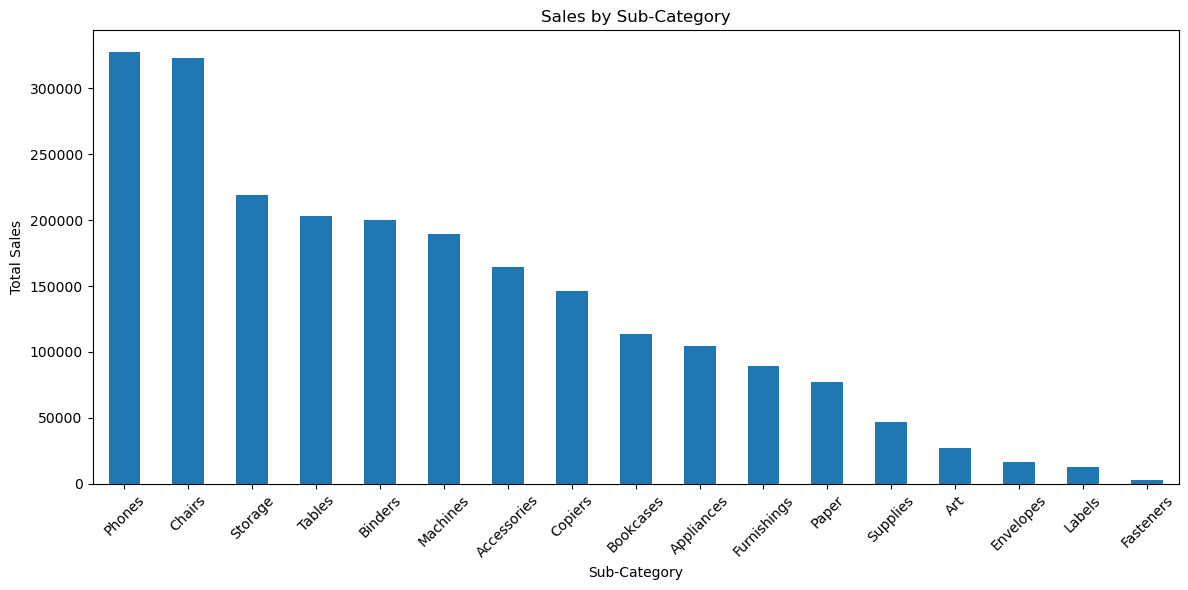

In [61]:
plt.figure(figsize=(12,6))

subcategory_sales.plot(kind="bar")

plt.title("Sales by Sub-Category")
plt.xlabel("Sub-Category")
plt.ylabel("Total Sales")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [62]:
top_products = df.groupby(
    "Product Name"
)["Sales"].sum().sort_values(ascending=False).head(10)

print(top_products)

Product Name
Canon imageCLASS 2200 Advanced Copier                                          61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind    27453.384
Cisco TelePresence System EX90 Videoconferencing Unit                          22638.480
HON 5400 Series Task Chairs for Big and Tall                                   21870.576
GBC DocuBind TL300 Electric Binding System                                     19823.479
GBC Ibimaster 500 Manual ProClick Binding System                               19024.500
Hewlett Packard LaserJet 3310 Copier                                           18839.686
HP Designjet T520 Inkjet Large Format Printer - 24" Color                      18374.895
GBC DocuBind P400 Electric Binding System                                      17965.068
High Speed Automatic Electric Letter Opener                                    17030.312
Name: Sales, dtype: float64


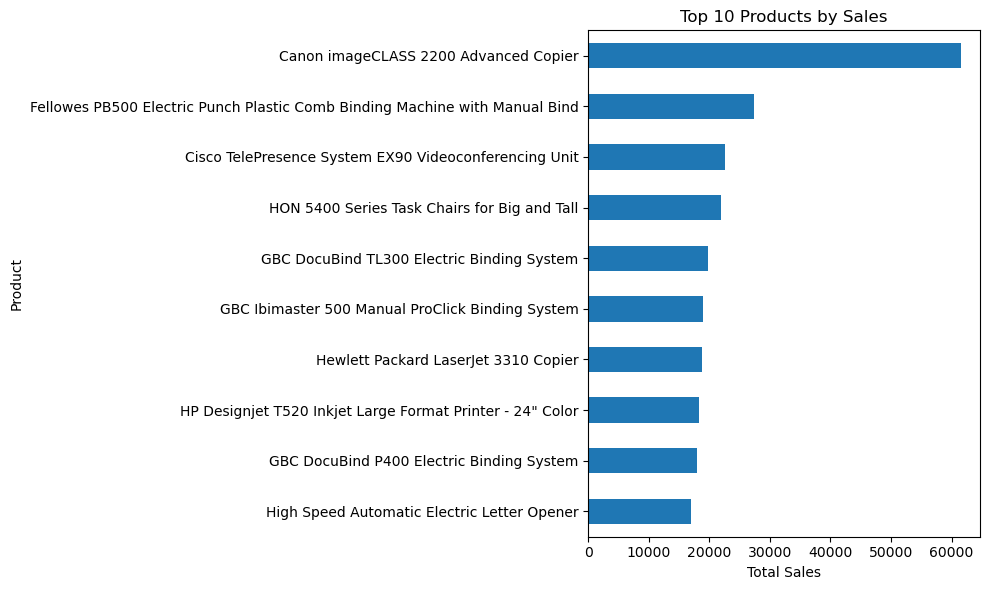

In [63]:
plt.figure(figsize=(10,6))

top_products.sort_values().plot(kind="barh")

plt.title("Top 10 Products by Sales")
plt.xlabel("Total Sales")
plt.ylabel("Product")

plt.tight_layout()
plt.show()

In [64]:
numeric_df = df.select_dtypes(include=np.number)

numeric_df.corr()

,Row ID,Postal Code,Sales,Year,Month
Row ID,1.000000,0.011298,0.001151,0.018851,-0.017940
Postal Code,0.011298,1.000000,-0.025756,0.022283,0.053265
Sales,0.001151,-0.025756,1.000000,-0.005242,-0.029634
Year,0.018851,0.022283,-0.005242,1.000000,-0.033570
Month,-0.017940,0.053265,-0.029634,-0.033570,1.000000


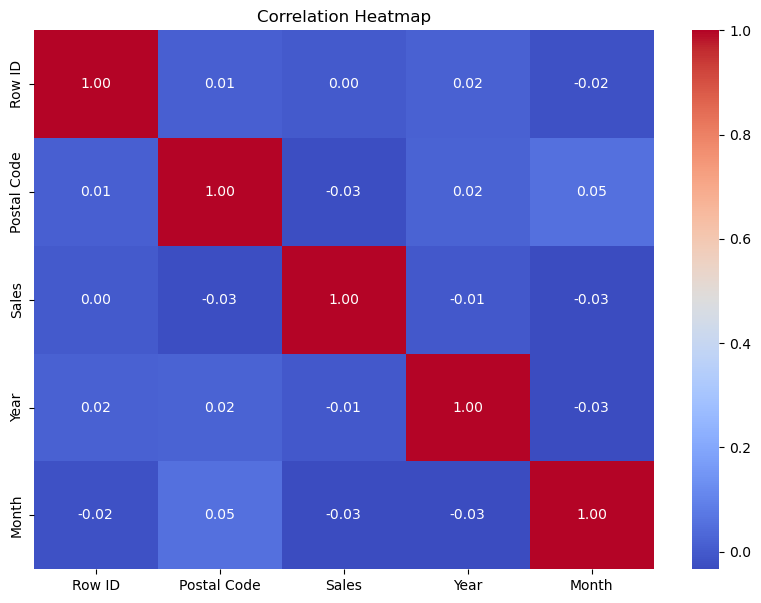

In [65]:
plt.figure(figsize=(10,7))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

In [66]:
monthly_sales

Order Date
2015-01-01    19546.1630
2015-02-01    11678.9940
2015-03-01     6716.0440
2015-04-01    12455.4820
2015-05-01    15165.0510
2015-06-01    11884.1690
2015-07-01    10075.7400
2015-08-01    26797.7630
2015-09-01    17158.9320
2015-10-01    10112.6410
2015-11-01    18349.7640
2015-12-01    17045.8427
2016-01-01    17701.6864
2016-02-01    13018.3150
2016-03-01    12207.4066
2016-04-01    11963.6960
2016-05-01    10483.4820
2016-06-01    13026.6682
2016-07-01    10706.7200
2016-08-01    22782.5770
2016-09-01    16484.9010
2016-10-01    12293.0380
2016-11-01    12139.0395
2016-12-01     9761.3330
2017-01-01    26342.5410
2017-02-01    42967.9150
2017-03-01    25982.2870
2017-04-01    19472.1640
2017-05-01    22649.3888
2017-06-01    14050.1430
2017-07-01    16501.0070
2017-08-01    24156.3226
2017-09-01     9789.6620
2017-10-01    22599.7820
2017-11-01    20378.2400
2017-12-01    21365.1485
2018-01-01    27367.5920
2018-02-01    36285.9360
2018-03-01    26882.9530
2018-04-01    

In [67]:
forecast_df = monthly_sales.reset_index()

forecast_df.columns = ["Date", "Sales"]

forecast_df.head()

,Date,Sales
0,2015-01-01,19546.163
1,2015-02-01,11678.994
2,2015-03-01,6716.044
3,2015-04-01,12455.482
4,2015-05-01,15165.051


In [31]:
forecast_df["Time"] = np.arange(len(forecast_df))

forecast_df.head()

,Date,Sales,Time
0,2015-01-01,14205.707,0
1,2015-02-01,4519.892,1
2,2015-03-01,55205.797,2
3,2015-04-01,27906.855,3
4,2015-05-01,23644.303,4


In [35]:
import numpy as np

forecast_df = monthly_sales.reset_index()
forecast_df.columns = ["Date", "Sales"]

forecast_df["Time"] = np.arange(len(forecast_df))

X = forecast_df[["Time"]]
y = forecast_df["Sales"]

print("Forecast Data:")
print(forecast_df.head())

print("\nX:")
print(X.head())

print("\ny:")
print(y.head())

Forecast Data:
        Date      Sales  Time
0 2015-01-01  14205.707     0
1 2015-02-01   4519.892     1
2 2015-03-01  55205.797     2
3 2015-04-01  27906.855     3
4 2015-05-01  23644.303     4

X:
   Time
0     0
1     1
2     2
3     3
4     4

y:
0    14205.707
1     4519.892
2    55205.797
3    27906.855
4    23644.303
Name: Sales, dtype: float64


In [36]:

split_point = int(len(forecast_df) * 0.8)

X_train = X.iloc[:split_point]
X_test = X.iloc[split_point:]

y_train = y.iloc[:split_point]
y_test = y.iloc[split_point:]

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 38
Testing samples: 10


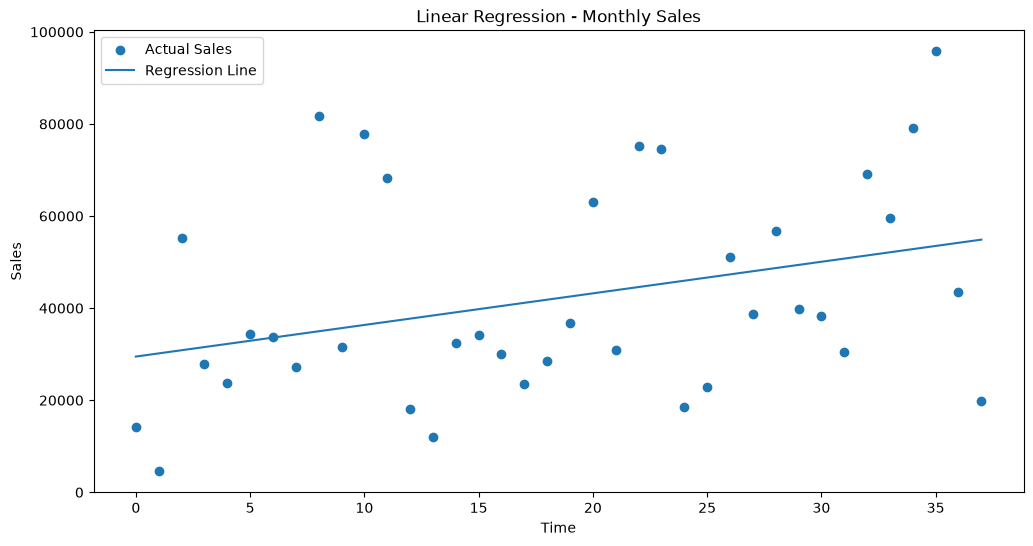

In [39]:
plt.figure(figsize=(12, 6))

plt.scatter(X_train, y_train, label="Actual Sales")

plt.plot(
    X_train,
    model.predict(X_train),
    label="Regression Line"
)

plt.title("Linear Regression - Monthly Sales")
plt.xlabel("Time")
plt.ylabel("Sales")

plt.legend()
plt.show()

In [40]:
y_pred = model.predict(X_test)

print("Predicted Sales:")
print(y_pred)


Predicted Sales:
[55563.60123585 56249.8827636  56936.16429134 57622.44581909
 58308.72734684 58995.00887459 59681.29040234 60367.57193009
 61053.85345784 61740.13498559]


In [41]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("RMSE:", rmse)
print("R² Score:", r2)

RMSE: 23619.289223453263
R² Score: 0.03323365449775528


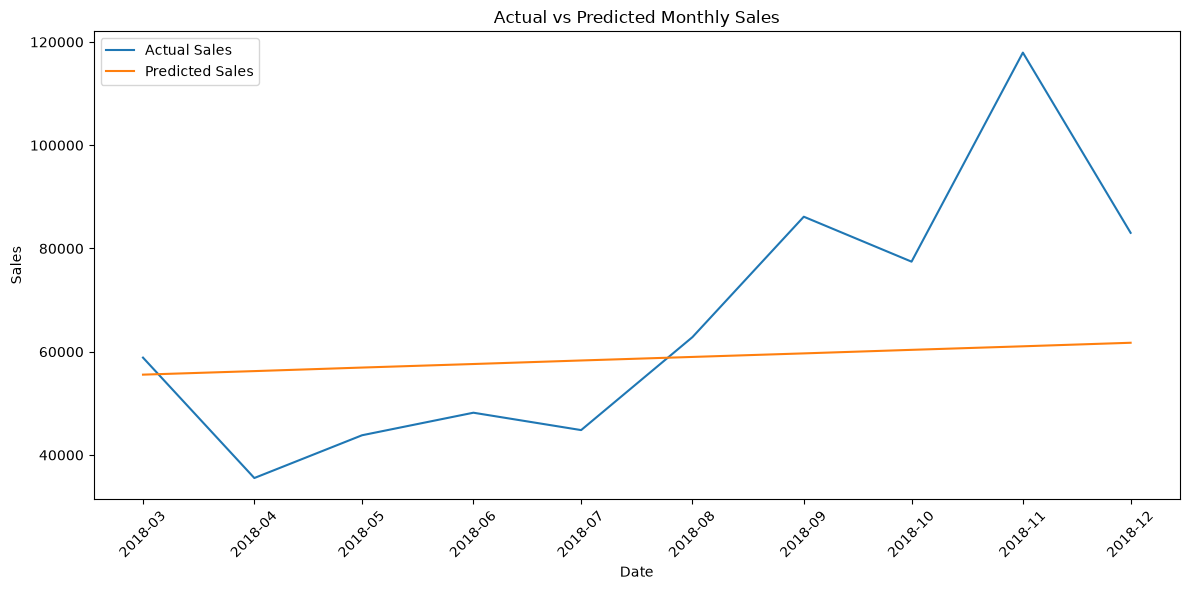

In [43]:
plt.figure(figsize=(12,6))

plt.plot(
    forecast_df["Date"].iloc[split_point:],
    y_test.values,
    label="Actual Sales"
)

plt.plot(
    forecast_df["Date"].iloc[split_point:],
    y_pred,
    label="Predicted Sales"
)

plt.title("Actual vs Predicted Monthly Sales")
plt.xlabel("Date")
plt.ylabel("Sales")

plt.legend()
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

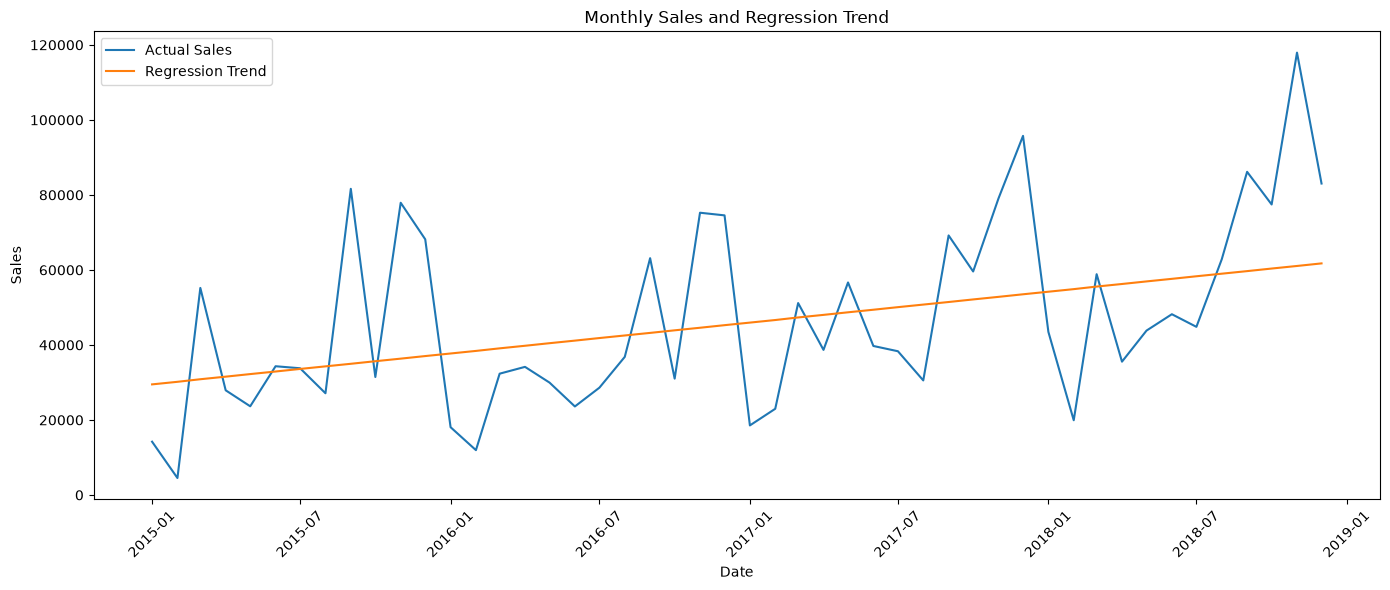

In [44]:
all_predictions = model.predict(X)

plt.figure(figsize=(14,6))

plt.plot(
    forecast_df["Date"],
    forecast_df["Sales"],
    label="Actual Sales"
)

plt.plot(
    forecast_df["Date"],
    all_predictions,
    label="Regression Trend"
)

plt.title("Monthly Sales and Regression Trend")
plt.xlabel("Date")
plt.ylabel("Sales")

plt.legend()

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [48]:
future_time = pd.DataFrame({
    "Time": np.arange(
        len(forecast_df),
        len(forecast_df) + 6
    )
})

future_predictions = model.predict(future_time)

last_date = forecast_df["Date"].max()

future_dates = pd.date_range(
    start=last_date + pd.DateOffset(months=1),
    periods=6,
    freq="MS"
)

future_forecast = pd.DataFrame({
    "Date": future_dates,
    "Forecasted Sales": future_predictions
})

print(future_forecast)


        Date  Forecasted Sales
0 2019-01-01      62426.416513
1 2019-02-01      63112.698041
2 2019-03-01      63798.979569
3 2019-04-01      64485.261097
4 2019-05-01      65171.542624
5 2019-06-01      65857.824152


In [49]:
future_forecast

,Date,Forecasted Sales
0,2019-01-01,62426.416513
1,2019-02-01,63112.698041
2,2019-03-01,63798.979569
3,2019-04-01,64485.261097
4,2019-05-01,65171.542624
5,2019-06-01,65857.824152


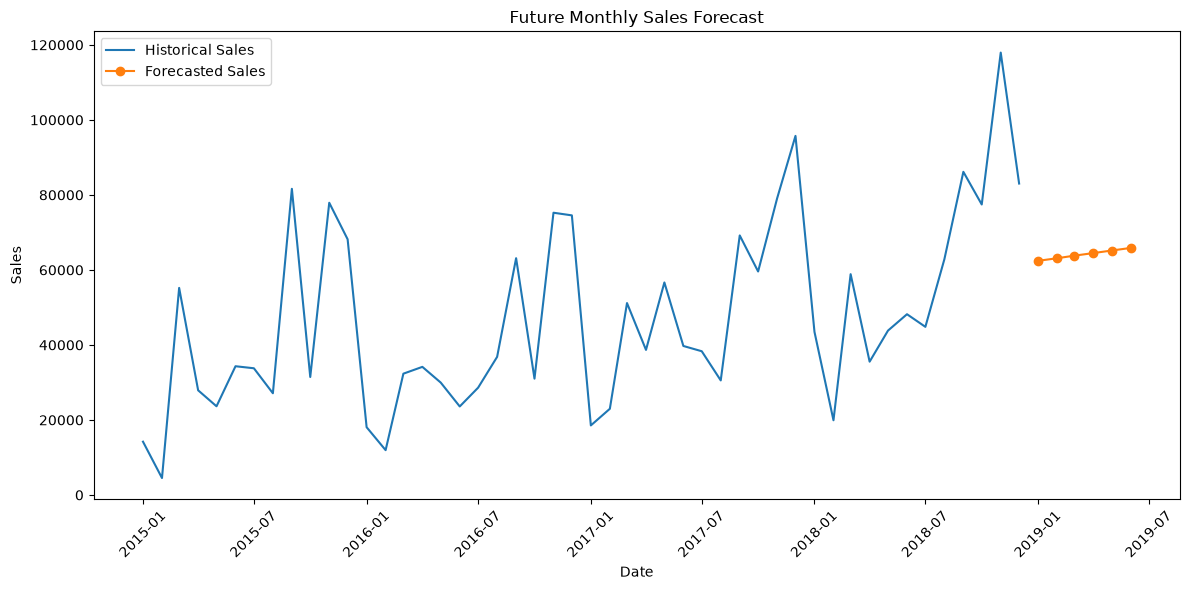

In [50]:
plt.figure(figsize=(12,6))

plt.plot(
    forecast_df["Date"],
    forecast_df["Sales"],
    label="Historical Sales"
)

plt.plot(
    future_forecast["Date"],
    future_forecast["Forecasted Sales"],
    marker="o",
    label="Forecasted Sales"
)

plt.title("Future Monthly Sales Forecast")
plt.xlabel("Date")
plt.ylabel("Sales")

plt.legend()

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [52]:
category_sales = df.groupby("Category")["Sales"].sum()

best_category = category_sales.idxmax()
best_category_sales = category_sales.max()

print("Category-wise Sales:")
print(category_sales)

print("\nBest Category:", best_category)
print("Sales:", best_category_sales)

Category-wise Sales:
Category
Furniture          728658.5757
Office Supplies    705422.3340
Technology         827455.8730
Name: Sales, dtype: float64

Best Category: Technology
Sales: 827455.873


In [54]:
region_sales = df.groupby("Region")["Sales"].sum().sort_values(ascending=False)

best_region = region_sales.idxmax()
best_region_sales = region_sales.max()

print("Region-wise Sales:")
print(region_sales)

print("\nBest Region:", best_region)
print("Sales:", best_region_sales)

Region-wise Sales:
Region
West       710219.6845
East       669518.7260
Central    492646.9132
South      389151.4590
Name: Sales, dtype: float64

Best Region: West
Sales: 710219.6845


In [56]:
top_products = df.groupby("Product Name")["Sales"].sum().sort_values(ascending=False).head(10)

best_product = top_products.index[0]
best_product_sales = top_products.iloc[0]

print("Top 10 Products:")
print(top_products)

print("\nTop Product:", best_product)
print("Sales:", best_product_sales)=

Top 10 Products:
Product Name
Canon imageCLASS 2200 Advanced Copier                                          61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind    27453.384
Cisco TelePresence System EX90 Videoconferencing Unit                          22638.480
HON 5400 Series Task Chairs for Big and Tall                                   21870.576
GBC DocuBind TL300 Electric Binding System                                     19823.479
GBC Ibimaster 500 Manual ProClick Binding System                               19024.500
Hewlett Packard LaserJet 3310 Copier                                           18839.686
HP Designjet T520 Inkjet Large Format Printer - 24" Color                      18374.895
GBC DocuBind P400 Electric Binding System                                      17965.068
High Speed Automatic Electric Letter Opener                                    17030.312
Name: Sales, dtype: float64

Top Product: Canon imageCLASS 2200 Advanced Copier


In [57]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("RMSE:", rmse)
print("R² Score:", r2)

RMSE: 23619.289223453263
R² Score: 0.03323365449775528


In [58]:
print(df.isnull().sum())


Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
dtype: int64


In [59]:
df["Postal Code"] = df["Postal Code"].fillna(0)

print(df.isnull().sum())

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
dtype: int64


In [60]:
mean_sales = df["Sales"].mean()
median_sales = df["Sales"].median()
std_sales = df["Sales"].std()

print("Mean Sales:", round(mean_sales, 2))
print("Median Sales:", round(median_sales, 2))
print("Standard Deviation:", round(std_sales, 2))

Mean Sales: 230.77
Median Sales: 54.49
Standard Deviation: 626.65


In [61]:
forecast_df = monthly_sales.reset_index()

forecast_df.columns = ["Date", "Sales"]

forecast_df["Time"] = np.arange(len(forecast_df))

forecast_df.head()

,Date,Sales,Time
0,2015-01-01,14205.707,0
1,2015-02-01,4519.892,1
2,2015-03-01,55205.797,2
3,2015-04-01,27906.855,3
4,2015-05-01,23644.303,4


In [62]:
X = forecast_df[["Time"]]
y = forecast_df["Sales"]

print("X:")
print(X.head())

print("\ny:")
print(y.head())


X:
   Time
0     0
1     1
2     2
3     3
4     4

y:
0    14205.707
1     4519.892
2    55205.797
3    27906.855
4    23644.303
Name: Sales, dtype: float64


In [63]:
future_time = pd.DataFrame({
    "Time": np.arange(
        len(forecast_df),
        len(forecast_df) + 6
    )
})

future_predictions = model.predict(future_time)

last_date = forecast_df["Date"].max()

future_dates = pd.date_range(
    start=last_date + pd.DateOffset(months=1),
    periods=6,
    freq="MS"
)

future_forecast = pd.DataFrame({
    "Date": future_dates,
    "Forecasted Sales": future_predictions
})

future_forecast["Forecasted Sales"] = future_forecast["Forecasted Sales"].round(2)

future_forecast


,Date,Forecasted Sales
0,2019-01-01,62426.42
1,2019-02-01,63112.70
2,2019-03-01,63798.98
3,2019-04-01,64485.26
4,2019-05-01,65171.54
5,2019-06-01,65857.82
